In [1]:
'''
기본적인 개념 : State, Node, Edge, Conditional Edge


State : 상태 - 현재 Agent의 상태(데이터)
Node  : Agent가 수행하는 작업(함수)
Edge  : Node 간의 관계를 설명(워크플로우)
Conditional Edge : Node 간의 관계를 설명(갈림길)
'''

'\n기본적인 개념 : State, Node, Edge, Conditional Edge\n\n\nState : 상태 - 현재 Agent의 상태(데이터)\nNode  : Agent가 수행하는 작업(함수)\nEdge  : Node 간의 관계를 설명(워크플로우)\nConditional Edge : Node 간의 관계를 설명(갈림길)\n'

In [2]:
import sys
sys.path.append('..')

from config import LLM, SMALL_LLM, SMART_LLM

In [3]:
query = '대손충당금에 대해서 설명해주세요'

## State

In [4]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

class AgentState(TypedDict):
    messages: list[Annotated[AnyMessage, add_messages]]     
# state update 시 Annotated의 두번째 인자를 보고 처리함

In [5]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

## Node - 무엇을 할지

In [6]:
def generate(state: AgentState) -> AgentState:
    messages = state['messages']
    ai_message = SMALL_LLM.invoke(messages)
    return {'messages': [ai_message]}

graph_builder.add_node('generate', generate)

## Edge - 어디로 갈지

In [7]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'generate')
graph_builder.add_edge('generate', END)

## Compile

In [8]:
graph = graph_builder.compile()

## 사용

In [9]:
from langchain_core.messages import HumanMessage

initial_state = {'messages': [HumanMessage(query)]}

In [10]:
initial_state

{'messages': [HumanMessage(content='대손충당금에 대해서 설명해주세요', additional_kwargs={}, response_metadata={})]}

In [11]:
graph.invoke(initial_state)

{'messages': [AIMessage(content='# 대손충당금(Allowance for Doubtful Accounts)\n\n## 📌 개념\n기업이 외상으로 판매한 상품이나 대여금 등으로 인해 **회수하지 못할 가능성이 있는 채권**에 대비하기 위해 미리 설정하는 충당금입니다.\n\n---\n\n## 🎯 필요성\n\n| 항목 | 설명 |\n|------|------|\n| **보수주의 원칙** | 미래의 손실을 미리 인식 |\n| **재무제표 신뢰성** | 실제 회수 가능한 금액만 자산으로 표시 |\n| **손실 예방** | 예상 손실에 대한 대비 |\n\n---\n\n## 💰 회계처리 방법\n\n### 1) **직접상각법**\n- 실제로 회수 불가능한 채권이 발생했을 때만 손실 인식\n- 소규모 기업에서 사용\n\n```\n[차변] 대손상각비 / [대변] 외상매출금\n```\n\n### 2) **충당금설정법** (일반적)\n- 매기말에 예상 대손액을 미리 계산하여 충당금 설정\n- 대규모 기업에서 사용\n\n```\n[차변] 대손상각비 / [대변] 대손충당금\n```\n\n---\n\n## 📊 계산 방법\n\n### ① **매출액 비율법**\n```\n대손충당금 = 당기 외상매출액 × 대손률(%)\n```\n\n### ② **외상채권 잔액 비율법**\n```\n대손충당금 = 기말 외상채권 잔액 × 대손률(%)\n```\n\n### ③ **개별 평가법**\n- 각 채권의 회수 가능성을 개별적으로 평가\n\n---\n\n## 📈 재무제표 표시\n\n**대차대조표(재무상태표)**\n```\n유동자산\n  외상매출금          1,000,000\n  대손충당금            (50,000)  ← 차감\n  순 외상매출금         950,000\n```\n\n**손익계산서**\n```\n판매비와관리비\n  대손상각비           50,000\n```\n\n---\n\n## ✅ 예시\n\n**상황**: 연말 외상매출금 1,000만원, 

## 시각화

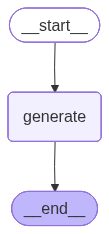

In [12]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))